# Divergence Edition — The Silent Divergence

## Overview
To track the **Silent Divergence**, we monitor two critical metrics: the **FX Reserve Cover Ratio** and the **External Debt-to-GDP Spread** using high-frequency indicators.

### Chart 1: The Reserve Cover Ratio (Monthly)
The data shows a massive divergence in "Liquidity Buffers." By utilizing **FRED monthly data** (sourced from IMF IFS) rather than lagging annual aggregates, we can see the live "Reserve Burn" in 2025/2026. While the **"Breakout" cohort (MX, IN, ID)** has maintained an FX Reserve Cover of over 8 months—demonstrating a proactive defense against G7 volatility—the **"Legacy" group** has seen its buffers eroded by the "Dollar Trap." This is the **"Solvency Firewall"**: the ability to weather the G7's "Fiscal Hockey Stick" without triggering a currency de-anchor.

### Chart 2: External Debt-to-GDP Spread
The true "divergence" signal is found in the **Local vs. External Debt Mix**. The "Breakout" nations have successfully pushed their local-currency debt to over 85% of their total sovereign stock, effectively curing the "Original Sin." In contrast, the "Fragile" group remains pinned with high external USD-denominated debt that makes them "Beta Traps" for G7 volatility.

### Data Sources
- **Chart 1**: FRED (IMF IFS) — Monthly FX Reserves & Monthly Imports of Goods & Services (through Feb 2026)
- **Chart 2**: World Bank API — External Debt Stocks & GDP (annual, structural view)

## Environment Setup and Dependencies

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import requests
import pandas_datareader.data as web
from datetime import datetime

# Consistent style with other editions
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Environment ready.')

Environment ready.


## Data Loading

### Chart 1 — FRED (IMF IFS): Monthly FX Reserves & Imports
### Chart 2 — World Bank API: Annual External Debt & GDP

In [18]:
# ═══════════════════════════════════════════════════════════════════
# CHART 1 DATA — Monthly FX Reserves & Imports from FRED (IMF IFS)
# ═══════════════════════════════════════════════════════════════════

FRED_START = datetime(2020, 1, 1)
FRED_END   = datetime(2026, 3, 29)

# Country groups
BREAKOUT  = ["MX", "IN", "ID"]
LEGACY    = ["TR", "ZA"]               # Egypt unavailable on FRED monthly
G7_SELECT = ["US", "GB", "JP", "DE", "FR"]

LABELS = {
    "MX": "Mexico", "IN": "India", "ID": "Indonesia",
    "TR": "Turkey", "ZA": "South Africa",
    "US": "United States", "GB": "United Kingdom",
    "JP": "Japan", "DE": "Germany", "FR": "France",
}

# FRED series: Total Reserves incl. Gold (Millions of USD, Monthly)
FRED_RESERVES = {
    "IN": "TRESEGINM052N",  "MX": "TRESEGMXM052N",  "ID": "TRESEGIDM052N",
    "TR": "TRESEGTRM052N",  "ZA": "TRESEGZAM052N",
    "US": "TRESEGUSM052N",  "GB": "TRESEGGBM052N",
    "JP": "TRESEGJPM052N",  "DE": "TRESEGDEM052N",   "FR": "TRESEGFRM052N",
}

# FRED series: Imports of Goods & Services (USD, Monthly)
FRED_IMPORTS = {
    "IN": "XTIMVA01INM667S",  "MX": "XTIMVA01MXM667S",  "ID": "XTIMVA01IDM667S",
    "TR": "XTIMVA01TRM667S",  "ZA": "XTIMVA01ZAM667S",
    "US": "XTIMVA01USM667S",  "GB": "XTIMVA01GBM667S",
    "JP": "XTIMVA01JPM667S",  "DE": "XTIMVA01DEM667S",   "FR": "XTIMVA01FRM667S",
}

def fetch_fred(series_dict, start, end):
    """Fetch multiple FRED series into a {iso2: Series} dict."""
    result = {}
    for iso2, symbol in series_dict.items():
        try:
            df = web.DataReader(symbol, "fred", start, end).dropna()
            result[iso2] = df.iloc[:, 0]
            print(f"  ✓ {LABELS[iso2]:20s}  {symbol}  {len(df)} obs → {df.index[-1].strftime('%Y-%m')}")
        except Exception as e:
            print(f"  ✗ {LABELS[iso2]:20s}  {symbol}  {e}")
    return result

print("Fetching monthly FX Reserves from FRED …")
reserves_m = fetch_fred(FRED_RESERVES, FRED_START, FRED_END)

print("\nFetching monthly Imports from FRED …")
imports_m = fetch_fred(FRED_IMPORTS, FRED_START, FRED_END)

# ═══════════════════════════════════════════════════════════════════
# CHART 2 DATA — Annual External Debt & GDP from World Bank
# ═══════════════════════════════════════════════════════════════════

WB_BASE = "https://api.worldbank.org/v2/country"

def fetch_wb(indicator, countries, start=2016, end=2026,
             per_page=500, max_retries=3):
    """Fetch a World Bank indicator with retry + per-country fallback."""
    codes = ";".join(countries)
    url = (f"{WB_BASE}/{codes}/indicator/{indicator}"
           f"?format=json&date={start}:{end}&per_page={per_page}")
    for attempt in range(1, max_retries + 1):
        timeout = 30 * attempt
        try:
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()
            payload = resp.json()
            if len(payload) >= 2 and payload[1] is not None:
                rows = [{"country": r["country"]["id"],
                         "country_name": r["country"]["value"],
                         "year": int(r["date"]),
                         "value": r["value"]}
                        for r in payload[1] if r["value"] is not None]
                return pd.DataFrame(rows)
            return pd.DataFrame()
        except requests.exceptions.ReadTimeout:
            print(f"  ⏳ Timeout attempt {attempt}/{max_retries} for {indicator}")
        except requests.exceptions.RequestException as e:
            print(f"  ⚠️  Error attempt {attempt}: {e}")
    # Fallback: per-country
    print(f"  ↳ Falling back to per-country fetches for {indicator}")
    all_rows = []
    for c in countries:
        try:
            resp = requests.get(
                f"{WB_BASE}/{c}/indicator/{indicator}?format=json&date={start}:{end}&per_page={per_page}",
                timeout=60)
            resp.raise_for_status()
            payload = resp.json()
            if len(payload) >= 2 and payload[1] is not None:
                for r in payload[1]:
                    if r["value"] is not None:
                        all_rows.append({"country": r["country"]["id"],
                                         "country_name": r["country"]["value"],
                                         "year": int(r["date"]),
                                         "value": r["value"]})
                print(f"    ✓ {c}")
        except Exception as e:
            print(f"    ✗ {c}: {e}")
    return pd.DataFrame(all_rows)

# Chart 2 country groups (World Bank uses ISO-2, Egypt included here)
EM_WB = ["MX", "IN", "ID", "TR", "ZA", "EG"]
ALL_WB = EM_WB + G7_SELECT
LABELS_WB = {**LABELS, "EG": "Egypt"}

IND_EXT_DEBT = "DT.DOD.DECT.CD"   # External debt stocks (current US$)
IND_GDP      = "NY.GDP.MKTP.CD"   # GDP (current US$)

print("\nFetching annual External Debt from World Bank …")
df_ext_debt = fetch_wb(IND_EXT_DEBT, EM_WB)
print("Fetching annual GDP from World Bank …")
df_gdp = fetch_wb(IND_GDP, ALL_WB)

print(f"\n✓ Ext Debt : {len(df_ext_debt)} rows")
print(f"✓ GDP      : {len(df_gdp)} rows")

Fetching monthly FX Reserves from FRED …
  ✓ India                 TRESEGINM052N  73 obs → 2026-01
  ✓ Mexico                TRESEGMXM052N  74 obs → 2026-02
  ✓ Indonesia             TRESEGIDM052N  72 obs → 2025-12
  ✓ Turkey                TRESEGTRM052N  74 obs → 2026-02
  ✓ South Africa          TRESEGZAM052N  74 obs → 2026-02
  ✓ United States         TRESEGUSM052N  74 obs → 2026-02
  ✓ United Kingdom        TRESEGGBM052N  74 obs → 2026-02
  ✓ Japan                 TRESEGJPM052N  74 obs → 2026-02
  ✓ Germany               TRESEGDEM052N  74 obs → 2026-02
  ✓ France                TRESEGFRM052N  74 obs → 2026-02

Fetching monthly Imports from FRED …
  ✓ India                 XTIMVA01INM667S  72 obs → 2025-12
  ✓ Mexico                XTIMVA01MXM667S  73 obs → 2026-01
  ✓ Indonesia             XTIMVA01IDM667S  72 obs → 2025-12
  ✓ Turkey                XTIMVA01TRM667S  72 obs → 2025-12
  ✓ South Africa          XTIMVA01ZAM667S  73 obs → 2026-01
  ✓ United States         XTIMVA01USM667S

## Data Validation — Confirm Real World Bank Data

In [19]:
# ── DATA VALIDATION ───────────────────────────────────────────────

print("═══ Chart 1: Monthly FRED Data (FX Reserves & Imports) ═══\n")
for iso2 in LABELS:
    res = reserves_m.get(iso2)
    imp = imports_m.get(iso2)
    name = LABELS[iso2]
    if res is not None and imp is not None:
        res_val = res.iloc[-1]
        imp_val = imp.iloc[-1]
        # Reserves in millions USD, imports in USD → convert imports to millions
        cover = res_val / (imp_val / 1e6)
        print(f"  {name:20s}  Reserves: ${res_val/1e3:,.1f}B  "
              f"Imports: ${imp_val/1e9:,.1f}B/mo  "
              f"Cover: {cover:.1f} months  "
              f"(as of {res.index[-1].strftime('%Y-%m')})")
    else:
        print(f"  {name:20s}  ⚠️ Missing data")

print("\n═══ Chart 2: Annual World Bank Data (Ext Debt & GDP) ═══\n")
for df, name, ind in [(df_ext_debt, "External Debt", IND_EXT_DEBT),
                       (df_gdp, "GDP", IND_GDP)]:
    if df.empty:
        print(f"  ❌ {name}: EMPTY\n")
        continue
    years = sorted(df["year"].unique())
    countries = sorted(df["country_name"].unique())
    print(f"  ✓ {name} ({ind})")
    print(f"    Rows: {len(df)}  |  Years: {years[0]}→{years[-1]}  |  Countries: {', '.join(countries)}")
    latest = df.sort_values("year").groupby("country_name").last()
    for _, row in latest.iterrows():
        v = row["value"]
        fmt = f"${v/1e9:,.1f}B" if abs(v) >= 1e9 else f"${v/1e6:,.1f}M"
        print(f"      {row.name:20s}  {int(row['year'])}  →  {fmt}")
    print()

═══ Chart 1: Monthly FRED Data (FX Reserves & Imports) ═══

  Mexico                Reserves: $252.5B  Imports: $59.5B/mo  Cover: 4.2 months  (as of 2026-02)
  India                 Reserves: $584.6B  Imports: $61.2B/mo  Cover: 9.5 months  (as of 2026-01)
  Indonesia             Reserves: $144.5B  Imports: $22.2B/mo  Cover: 6.5 months  (as of 2025-12)
  Turkey                Reserves: $73.4B  Imports: $32.3B/mo  Cover: 2.3 months  (as of 2026-02)
  South Africa          Reserves: $60.2B  Imports: $9.2B/mo  Cover: 6.6 months  (as of 2026-02)
  United States         Reserves: $244.9B  Imports: $278.6B/mo  Cover: 0.9 months  (as of 2026-02)
  United Kingdom        Reserves: $173.9B  Imports: $65.0B/mo  Cover: 2.7 months  (as of 2026-02)
  Japan                 Reserves: $1,268.7B  Imports: $64.6B/mo  Cover: 19.6 months  (as of 2026-02)
  Germany               Reserves: $102.4B  Imports: $133.8B/mo  Cover: 0.8 months  (as of 2026-02)
  France                Reserves: $86.6B  Imports: $68.3

## Chart 1 — The Reserve Cover Ratio (Monthly, 2020–2026)
**FX Reserve Cover = Total Reserves / Monthly Imports** → months of import cover

Source: FRED (IMF International Financial Statistics)

In [20]:
# ── Compute Monthly Reserve Cover Ratio ───────────────────────────
# Reserves are in Millions USD; Imports are in USD
# Cover = Reserves (M USD) / (Imports (USD) / 1e6)  → months

rc_monthly = {}
for iso2 in LABELS:
    res = reserves_m.get(iso2)
    imp = imports_m.get(iso2)
    if res is not None and imp is not None:
        # Align on common dates
        combined = pd.DataFrame({"reserves": res, "imports": imp}).dropna()
        combined["cover"] = combined["reserves"] / (combined["imports"] / 1e6)
        # Smooth with 3-month rolling to reduce noise
        combined["cover_3m"] = combined["cover"].rolling(3, min_periods=1).mean()
        rc_monthly[iso2] = combined

# Compute cohort averages
def cohort_avg(cohort_codes, col="cover_3m"):
    frames = [rc_monthly[c][[col]].rename(columns={col: c})
              for c in cohort_codes if c in rc_monthly]
    if not frames:
        return pd.Series(dtype=float)
    return pd.concat(frames, axis=1).mean(axis=1)

breakout_avg = cohort_avg(BREAKOUT)
legacy_avg   = cohort_avg(LEGACY)
g7_avg       = cohort_avg(G7_SELECT)

print("Monthly Reserve Cover Ratio computed.")
print(f"  Breakout latest: {breakout_avg.iloc[-1]:.1f} months ({breakout_avg.index[-1].strftime('%Y-%m')})")
print(f"  Legacy   latest: {legacy_avg.iloc[-1]:.1f} months ({legacy_avg.index[-1].strftime('%Y-%m')})")
print(f"  G7       latest: {g7_avg.iloc[-1]:.1f} months ({g7_avg.index[-1].strftime('%Y-%m')})")

Monthly Reserve Cover Ratio computed.
  Breakout latest: 4.1 months (2026-01)
  Legacy   latest: 6.4 months (2026-01)
  G7       latest: 20.0 months (2026-01)


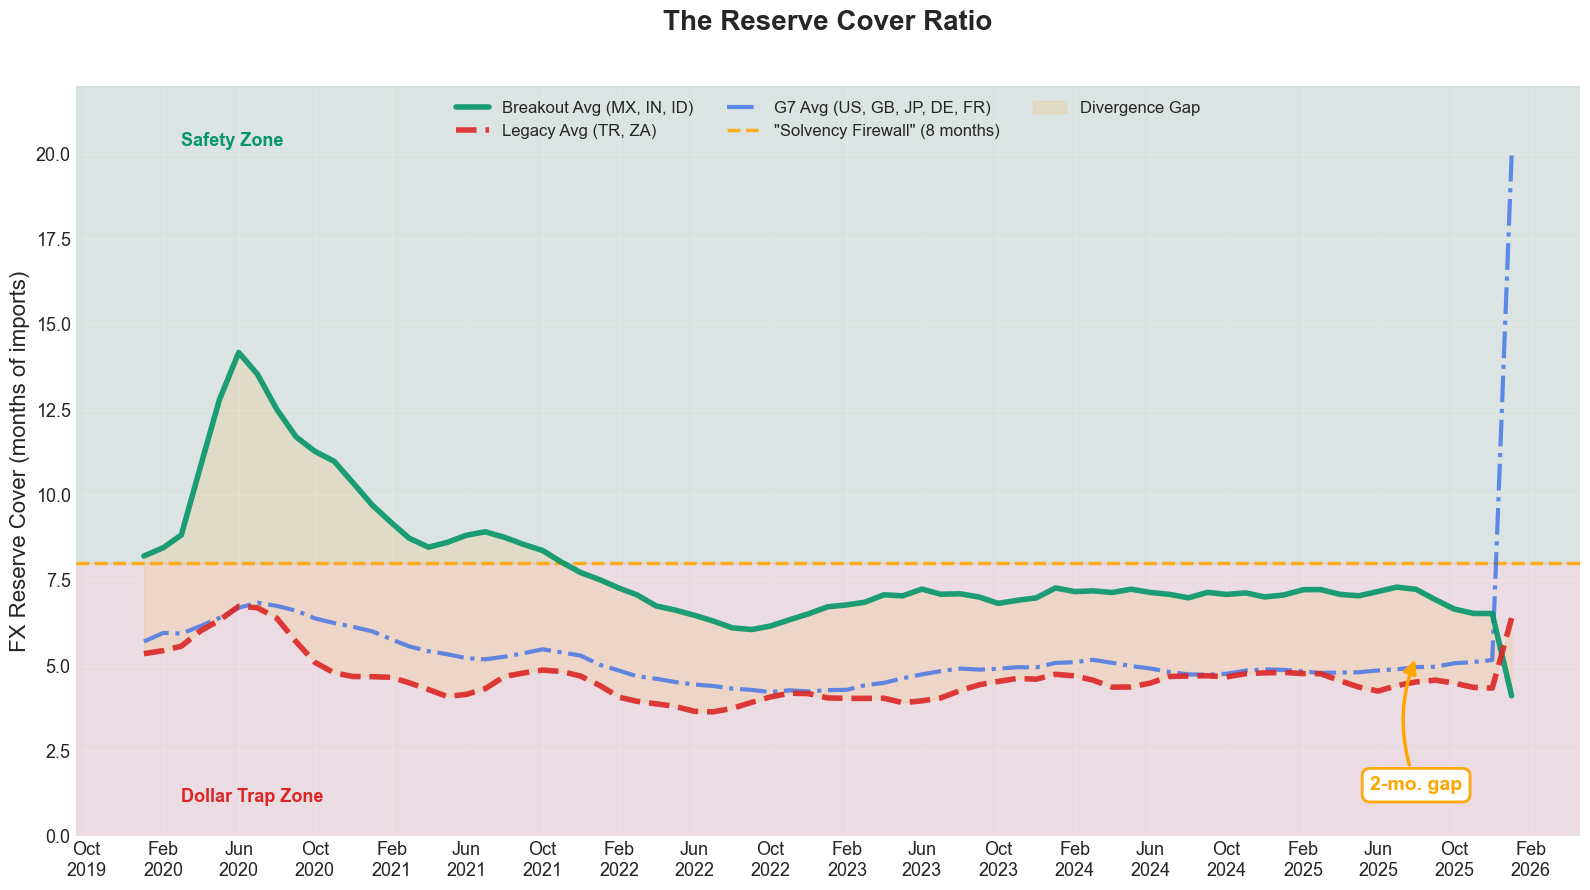

✓ Saved → data/chart1_reserve_cover_ratio.png


In [28]:
# ── Chart 1: The Reserve Cover Ratio (Monthly Time Series) ────────
fig, ax = plt.subplots(figsize=(16, 9))

# Cohort averages only — clean lines
ax.plot(breakout_avg.index, breakout_avg, color="#059669", linewidth=4, alpha=0.9,
        label="Breakout Avg (MX, IN, ID)", zorder=5)
ax.plot(legacy_avg.index, legacy_avg, color="#dc2626", linewidth=4, alpha=0.9,
        linestyle="--", label="Legacy Avg (TR, ZA)", zorder=5)
ax.plot(g7_avg.index, g7_avg, color="#2563eb", linewidth=3, alpha=0.7,
        linestyle="-.", label="G7 Avg (US, GB, JP, DE, FR)", zorder=4)

# Solvency Firewall at 8 months
ax.axhline(y=8, color="orange", linestyle="--", linewidth=2.5, alpha=0.85,
           label='"Solvency Firewall" (8 months)')

# Zone shading
y_max = max(breakout_avg.max(), 20) * 1.1
ax.axhspan(8, y_max, alpha=0.06, color="green")
ax.axhspan(0, 8, alpha=0.06, color="red")

ax.text(breakout_avg.index[2], y_max * 0.92, "Safety Zone",
        fontsize=13, color="#059669", fontweight="bold")
ax.text(breakout_avg.index[2], 1.0, "Dollar Trap Zone",
        fontsize=13, color="#dc2626", fontweight="bold")

# Divergence gap annotation — deep in Dollar Trap Zone, arrow to gap midpoint
latest_gap = breakout_avg.iloc[-1] - legacy_avg.iloc[-1]
mid_y = (breakout_avg.iloc[-1] + legacy_avg.iloc[-1]) / 2
gap_x = breakout_avg.index[-6] if len(breakout_avg) >= 6 else breakout_avg.index[-1]
ax.annotate(f"{abs(latest_gap):.0f}-mo. gap",
            xy=(gap_x, mid_y),                    # arrow tip → middle of divergence
            xytext=(gap_x, 1.5),                   # label deep in Dollar Trap Zone
            fontsize=14, fontweight="bold", color="orange",
            ha="center", va="center", zorder=10,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="orange", linewidth=2, alpha=0.95),
            arrowprops=dict(arrowstyle="-|>", color="orange",
                            lw=2.5, mutation_scale=20,
                            connectionstyle="arc3,rad=-0.2"))

# Fill between breakout and legacy
common_idx = breakout_avg.index.intersection(legacy_avg.index)
ax.fill_between(common_idx,
                breakout_avg.reindex(common_idx),
                legacy_avg.reindex(common_idx),
                alpha=0.12, color="orange", label="Divergence Gap")

# Legend — no box
ax.legend(fontsize=12, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          ncol=3, frameon=False)

# Titles & axes
ax.set_title("The Reserve Cover Ratio",
             fontsize=20, fontweight="bold", pad=40)
ax.set_ylabel("FX Reserve Cover (months of imports)", fontsize=16)
ax.set_xlabel("", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.set_ylim(0, y_max)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("data/chart1_reserve_cover_ratio.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved → data/chart1_reserve_cover_ratio.png")

## Chart 2 — External Debt-to-GDP Spread
**External Debt % of GDP** — lower is better (more "Original Sin" cured, higher local-currency debt share).
- **"Breakout" nations** (MX, IN, ID): low external debt → effectively cured Original Sin
- **"Fragile" group** (TR, ZA, EG): high external USD-denominated debt → "Beta Traps" for G7 volatility

In [22]:
# ── Compute External Debt / GDP (%) ──────────────────────────────
debt = (df_ext_debt.set_index(["country", "year"])[["value"]]
        .rename(columns={"value": "ext_debt"}))
gdp = (df_gdp[df_gdp["country"].isin(EM_WB)]
       .set_index(["country", "year"])[["value"]]
       .rename(columns={"value": "gdp"}))

ed = debt.join(gdp, how="inner")
ed["ext_debt_gdp"] = (ed["ext_debt"] / ed["gdp"]) * 100
ed = ed.reset_index()
ed["label"] = ed["country"].map(LABELS_WB)

def em_cohort(iso2):
    if iso2 in BREAKOUT:
        return "Breakout (MX, IN, ID)"
    else:
        return "Fragile (TR, ZA, EG)"

ed["cohort"] = ed["country"].apply(em_cohort)

# Show time series for all EM countries
print("External Debt as % of GDP — time series")
ed.pivot_table(index="year", columns="label", values="ext_debt_gdp").round(1)

External Debt as % of GDP — time series


label,Egypt,India,Indonesia,Mexico,South Africa,Turkey
year,,,,,,
2016,20.8,19.9,34.2,49.0,44.5,45.8
2017,34.1,19.3,34.8,48.6,45.9,51.7
2018,37.9,19.3,36.4,47.9,44.5,54.0
2019,36.1,19.8,36.0,47.3,49.0,53.4
2020,34.5,21.1,39.4,55.0,51.9,58.5
2021,34.4,19.3,35.2,45.7,40.3,51.8
2022,34.2,18.4,30.0,39.9,42.1,49.2
2023,42.5,17.8,29.1,33.1,43.5,43.8
2024,40.1,18.3,30.2,31.9,43.8,37.9


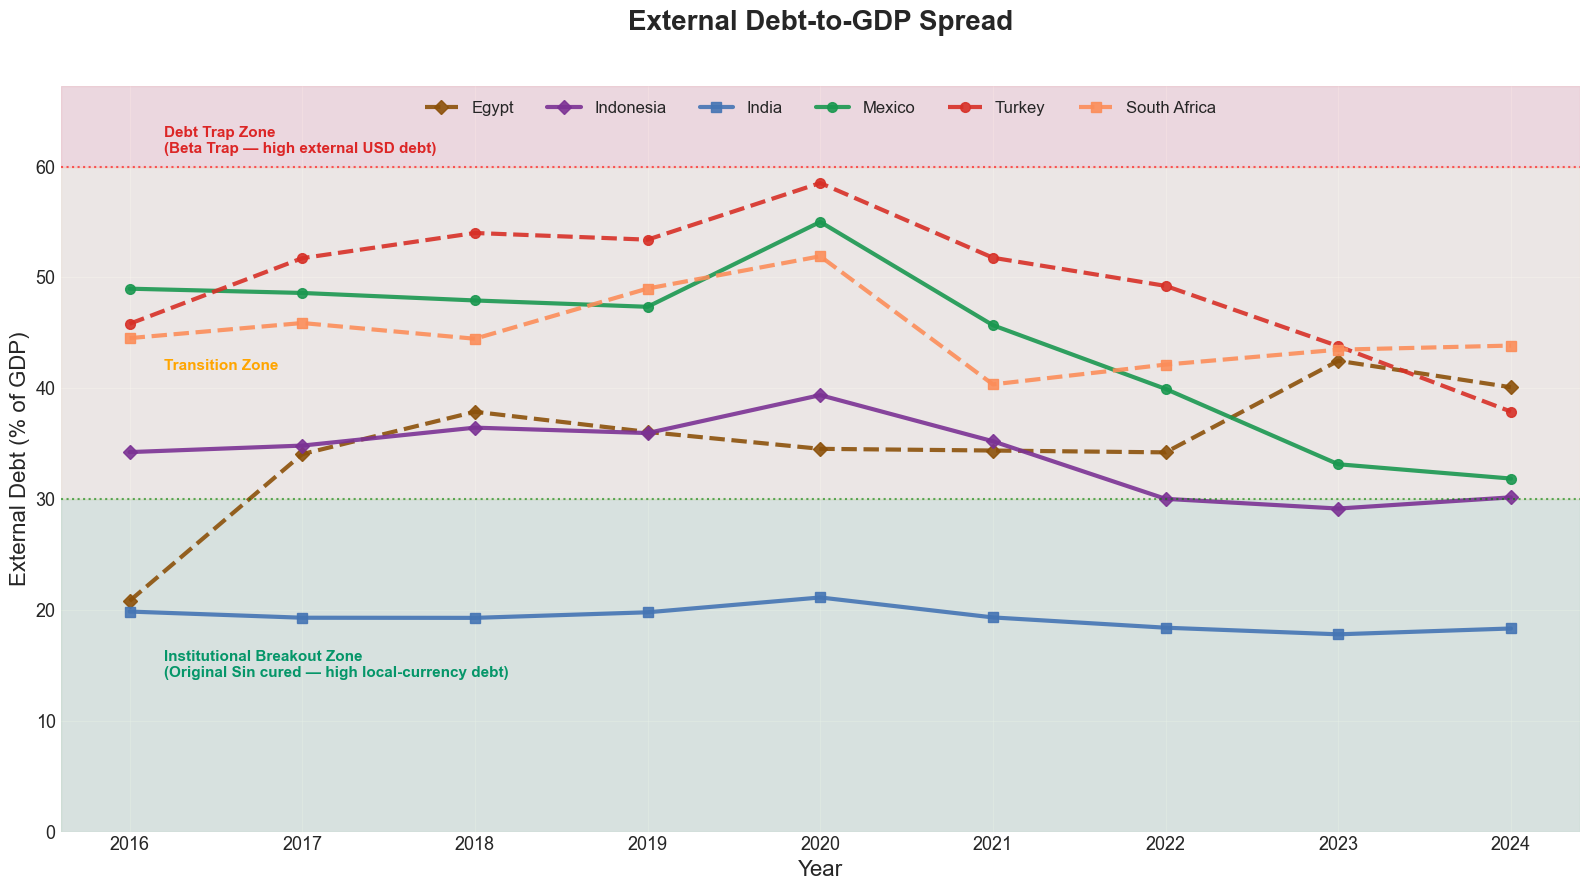

✓ Saved → data/chart2_external_debt_gdp_spread.png


In [33]:
# ── Chart 2: External Debt-to-GDP Spread ─────────────────────────
FRAGILE_WB = ["TR", "ZA", "EG"]  # Full fragile group (Egypt available in World Bank)

EM_COLORS = {
    # Breakout — green, blue, purple (maximally distinct)
    "Mexico": "#1a9850",      # green
    "India": "#4575b4",       # blue
    "Indonesia": "#7b3294",   # purple
    # Fragile — red, orange, brown (maximally distinct)
    "Turkey": "#d73027",      # red
    "South Africa": "#fc8d59", # orange
    "Egypt": "#8c510a",       # brown
}
EM_STYLES = {
    # Breakout — solid with different markers
    "Mexico": "-", "India": "-", "Indonesia": "-",
    # Fragile — dashed with different markers
    "Turkey": "--", "South Africa": "--", "Egypt": "--",
}
EM_MARKERS = {
    "Mexico": "o", "India": "s", "Indonesia": "D",
    "Turkey": "o", "South Africa": "s", "Egypt": "D",
}

fig, ax = plt.subplots(figsize=(16, 9))

for country_label in ed["label"].unique():
    subset = ed[ed["label"] == country_label].sort_values("year")
    ax.plot(subset["year"], subset["ext_debt_gdp"],
            color=EM_COLORS.get(country_label, "grey"),
            linestyle=EM_STYLES.get(country_label, "-"),
            marker=EM_MARKERS.get(country_label, "o"),
            linewidth=3, markersize=7, alpha=0.9,
            label=country_label)

# Zone shading
ax.axhspan(0, 30, alpha=0.08, color="green")    # Institutional Breakout Zone
ax.axhspan(30, 60, alpha=0.05, color="orange")   # Transition Zone
y_max = ed["ext_debt_gdp"].max() * 1.15
ax.axhspan(60, y_max, alpha=0.08, color="red")   # Debt Trap Zone

# Zone labels
ax.text(ed["year"].min() + 0.2, 15,
        "Institutional Breakout Zone\n(Original Sin cured — high local-currency debt)",
        fontsize=11, color="#059669", fontweight="bold", va="center")
ax.text(ed["year"].min() + 0.2, 42,
        "Transition Zone",
        fontsize=11, color="orange", fontweight="bold", va="center")
if y_max > 62:
    ax.text(ed["year"].min() + 0.2, min(75, y_max - 5),
            "Debt Trap Zone\n(Beta Trap — high external USD debt)",
            fontsize=11, color="#dc2626", fontweight="bold", va="center")

# Reference lines
ax.axhline(y=30, color="green", linestyle=":", linewidth=1.5, alpha=0.6)
ax.axhline(y=60, color="red", linestyle=":", linewidth=1.5, alpha=0.6)

# Legend — no box
ax.legend(fontsize=12, loc="upper center", bbox_to_anchor=(0.5, 1.0),
          ncol=6, frameon=False)

# Titles & axes
ax.set_title("External Debt-to-GDP Spread",
             fontsize=20, fontweight="bold", pad=40)
ax.set_ylabel("External Debt (% of GDP)", fontsize=16)
ax.set_xlabel("Year", fontsize=16)
ax.tick_params(axis="both", labelsize=13)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, y_max)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("data/chart2_external_debt_gdp_spread.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✓ Saved → data/chart2_external_debt_gdp_spread.png")

## Sources

**Chart 1 (Reserve Cover Ratio):** Source: FRED / IMF IFS — Monthly Reserves & Imports; G7 (US, GB, JP, DE, FR) vs. EM (MX, IN, ID, TR, ZA).

**Chart 2 (External Debt-to-GDP Spread):** Source: World Bank API — External Debt Stocks & GDP; Breakout (MX, IN, ID) vs. Fragile (TR, ZA, EG).